In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import mplhep as hep
from matplotlib.patches import Rectangle
from pathlib import Path
from typing import List, Union
from scipy.linalg import solve_triangular, qr
import json
import re
import os
import uproot
import importlib.util
plt.style.use(hep.style.CMS)

In [ ]:
label_map_nj = {
     'nj_bin0': 'r_NJ_0p0_1p0',
 'nj_bin1': 'r_NJ_1p0_2p0',
 'nj_bin2': 'r_NJ_2p0_3p0',
 'nj_bin3': 'r_NJ_3p0_4p0',
 'nj_bin4': 'r_NJ_4p0_100p0',
}


pois = {
    "PTH": ["r_PTH_0p0_5p0","r_PTH_5p0_10p0","r_PTH_10p0_15p0","r_PTH_15p0_20p0","r_PTH_20p0_25p0","r_PTH_25p0_30p0","r_PTH_30p0_35p0","r_PTH_35p0_45p0","r_PTH_45p0_60p0","r_PTH_60p0_80p0","r_PTH_80p0_100p0","r_PTH_100p0_120p0","r_PTH_120p0_140p0","r_PTH_140p0_170p0","r_PTH_170p0_200p0","r_PTH_200p0_250p0","r_PTH_250p0_350p0","r_PTH_350p0_450p0","r_PTH_450p0_10000p0"],
    "NJ": ["r_NJ_0p0_1p0", "r_NJ_1p0_2p0", "r_NJ_2p0_3p0", "r_NJ_3p0_4p0", "r_NJ_4p0_100p0"],
    "PTJ0": ["r_PTJ0_m10000p0_30p0", "r_PTJ0_30p0_40p0", "r_PTJ0_40p0_55p0", "r_PTJ0_55p0_75p0", "r_PTJ0_75p0_95p0", "r_PTJ0_95p0_120p0", "r_PTJ0_120p0_150p0", "r_PTJ0_150p0_200p0", "r_PTJ0_200p0_10000p0"],
    "YH": ["r_YH_0p0_0p15", "r_YH_0p15_0p3", "r_YH_0p3_0p45", "r_YH_0p45_0p6", "r_YH_0p6_0p75", "r_YH_0p75_0p9", "r_YH_0p9_1p2", "r_YH_1p2_1p6", "r_YH_1p6_2p0", "r_YH_2p0_2p5"]
}

In [20]:
palette = sns.diverging_palette(240, 10, n=20, as_cmap=True)


# Plot correlation matrix at gen-level
def plot_corr(_corr_gen, title="Correlation Matrix (Generator Level)", save_path=None, label_map=None):
    corr_gen_mask = np.triu(np.ones_like(_corr_gen, dtype=bool), k=1)
    fig_corr_gen, ax_corr_gen = plt.subplots(figsize=(28, 18), constrained_layout=True)
    sns.heatmap(
        _corr_gen,
        ax=ax_corr_gen,
        cmap=palette,
        mask=corr_gen_mask,
        vmin=-1,
        vmax=1,
        annot=True,
        fmt=".2f",
        center=0,
        square=True,
        annot_kws={"size": 10, "weight": "bold"},
        cbar_kws={"label": "Correlation"},
    )
    ax_corr_gen.set_title(title)
    ax_corr_gen.set_xlabel("Bins")
    ax_corr_gen.set_ylabel("Bins")
    
    # ---- LABEL TRANSLATION LOGIC ----
    if label_map is not None:
        # assume index == columns order
        original_labels = list(_corr_gen.index)

        translated_labels = [
            label_map.get(lbl, lbl) for lbl in original_labels
        ]

        ax_corr_gen.set_xticklabels(translated_labels, rotation=90, fontsize=12)
        ax_corr_gen.set_yticklabels(translated_labels, rotation=0, fontsize=12)
        # IMPORTANT: re-apply tick styling AFTER setting labels
        ax_corr_gen.tick_params(
            axis="x",
            which="both",
            length=0,   # <- removes tick marks
            bottom=False,
            top=False
        )
        ax_corr_gen.tick_params(
            axis="y",
            which="both",
            length=0,   # <- removes tick marks
            left=False,
            right=False
        )

    else:
        ax_corr_gen.tick_params(
            axis="x", which="both", labelrotation=90, bottom=False, top=False, length=0, labelsize=12
        )
        ax_corr_gen.tick_params(
            axis="y", which="both", labelrotation=0, left=False, right=False, length=0, labelsize=12
        )

    ax_corr_gen.minorticks_off()

    if save_path:
        plt.savefig(save_path, dpi=300)
    else:
        plt.show()

# Plot covariance matrix at gen-level
def plot_cov(_corr_gen, title="Covariance Matrix (Generator Level)", save_path=None, label_map=None):
    corr_gen_mask = np.triu(np.ones_like(_corr_gen, dtype=bool), k=1)
    fig_corr_gen, ax_corr_gen = plt.subplots(figsize=(28, 18), constrained_layout=True)
    sns.heatmap(
        _corr_gen,
        ax=ax_corr_gen,
        cmap=palette,
        mask=corr_gen_mask,
        vmin = _corr_gen.to_numpy().min(),
        vmax = _corr_gen.to_numpy().max(),
        annot=True,
        fmt=".2f",
        center=0,
        square=True,
        annot_kws={"size": 10, "weight": "bold"},
        cbar_kws={"label": r"Theoretical Covariance [fb$^{2}$]"},
        # cbar_kws={"label": "Theoretical Covariance"},
    )
    ax_corr_gen.set_title(title)
    ax_corr_gen.set_xlabel("Bins")
    ax_corr_gen.set_ylabel("Bins")
    
    # ---- LABEL TRANSLATION LOGIC ----
    if label_map is not None:
        # assume index == columns order
        original_labels = list(_corr_gen.index)

        translated_labels = [
            label_map.get(lbl, lbl) for lbl in original_labels
        ]

        ax_corr_gen.set_xticklabels(translated_labels, rotation=90, fontsize=12)
        ax_corr_gen.set_yticklabels(translated_labels, rotation=0, fontsize=12)
        # IMPORTANT: re-apply tick styling AFTER setting labels
        ax_corr_gen.tick_params(
            axis="x",
            which="both",
            length=0,   # <- removes tick marks
            bottom=False,
            top=False
        )
        ax_corr_gen.tick_params(
            axis="y",
            which="both",
            length=0,   # <- removes tick marks
            left=False,
            right=False
        )

    else:
        ax_corr_gen.tick_params(
            axis="x", which="both", labelrotation=90, bottom=False, top=False, length=0, labelsize=12
        )
        ax_corr_gen.tick_params(
            axis="y", which="both", labelrotation=0, left=False, right=False, length=0, labelsize=12
        )

    ax_corr_gen.minorticks_off()

    if save_path:
        plt.savefig(save_path, dpi=300)
    else:
        plt.show()


def corr_from_cov(cov_mat: pd.DataFrame) -> pd.DataFrame:
    v = np.diag(cov_mat.to_numpy())
    sigma = np.sqrt(np.clip(v, 0.0, None))
    with np.errstate(divide="ignore", invalid="ignore"):
        outer = np.outer(1.0 / sigma, 1.0 / sigma)
        arr = outer * cov_mat.to_numpy()
    arr = np.nan_to_num(arr, nan=0.0, posinf=0.0, neginf=0.0)
    np.fill_diagonal(arr, 1.0)
    return pd.DataFrame(arr, index=cov_mat.index, columns=cov_mat.columns)


In [7]:
### Kljinsma method

In [ ]:
FILE_RE = re.compile(
    r"^fidXS_(?P<obs>PTH)_all_scale(?P<scale>0|1|3|5|7|8)\.py$"
    # r"^fidXS_(?P<obs>PTH)_all_scale(?P<scale>0)\.py$"
)

def load_python_module(path: Path):
    spec = importlib.util.spec_from_file_location(path.stem, path)
    if spec is None or spec.loader is None:
        raise RuntimeError(f"Cannot load file: {path}")
    module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(module)
    return module

scale_variations = {
    "0": {
        "PTH": [],
        # "NJ": [],
        # "PTJ0": [],
        # "YH": [],
    },
    "1": {
        "PTH": [],
        # "NJ": [],
        # "PTJ0": [],
        # "YH": [],
    },
    "3": {
        "PTH": [],
        # "NJ": [],
        # "PTJ0": [],
        # "YH": [],
    },
    "5": {
        "PTH": [],
        # "NJ": [],
        # "PTJ0": [],
        # "YH": [],
    },
    "7": {
        "PTH": [],
        # "NJ": [],
        # "PTJ0": [],
        # "YH": [],
    },
    "8": {
        "PTH": [],
        # "NJ": [],
        # "PTJ0": [],
        # "YH": [],
    }
}

fidXS_folder = Path("theoretical_uncertainties/fidXS")

for path in fidXS_folder.iterdir():
    print(path)
    match = FILE_RE.match(path.name)
    if not match:
        continue

    obs = match.group("obs")
    scale = match.group("scale")

    module = load_python_module(path)

    if not hasattr(module, "fidXS"):
        print(f"Skipping {path.name}: no fidXS vector")
        continue

    sigma = np.array(list(module.fidXS))  # convert once to numpy
    up = np.array(list(module.fidXS_scale_up))
    dn = np.array(list(module.fidXS_scale_dn))
    
    scale_variations[scale][obs] = up - sigma
    # scale_variations[scale][obs] = 0.5*(up - dn)
    
    


theoretical_uncertainties/fidXS/__pycache__
theoretical_uncertainties/fidXS/fidXS_PTH_all_scale8.py
theoretical_uncertainties/fidXS/fidXS_PTH_all_scale0.py
theoretical_uncertainties/fidXS/fidXS_PTH_all_scale1.py
theoretical_uncertainties/fidXS/fidXS_PTH_all_scale3.py
theoretical_uncertainties/fidXS/fidXS_PTH_all_scale7.py
theoretical_uncertainties/fidXS/fidXS_PTH_all_scale5.py


In [47]:
scale_variations

{'0': {'PTH': array([0.57669492, 0.54900859, 0.3747744 , 0.24688453, 0.16032544,
         0.10946718, 0.07800062, 0.0556668 , 0.04152623, 0.03205519,
         0.02599166, 0.02042769, 0.01584763, 0.01325833, 0.02384728,
         0.02758954, 0.00897978, 0.00598719])},
 '1': {'PTH': array([0.59740326, 0.55956054, 0.37180218, 0.24313523, 0.15733898,
         0.10726924, 0.07595568, 0.05370696, 0.0403697 , 0.03071979,
         0.02499866, 0.01955333, 0.01503572, 0.01265794, 0.02257303,
         0.02594883, 0.00852989, 0.00564982])},
 '3': {'PTH': array([0.60164697, 0.56446145, 0.37009393, 0.23713429, 0.15277447,
         0.10427331, 0.07415456, 0.05337971, 0.0401957 , 0.03110473,
         0.02498703, 0.01977121, 0.01548361, 0.01297221, 0.02324518,
         0.02690441, 0.00888436, 0.00595075])},
 '5': {'PTH': array([0.64290759, 0.58651272, 0.36601161, 0.2303138 , 0.14684329,
         0.09958018, 0.06989843, 0.04946569, 0.03754313, 0.02842158,
         0.02291582, 0.0179443 , 0.01383923, 0.01

In [ ]:
import numpy as np
import pandas as pd

observables = ["PTH"]
bin_info = {
    "PTH": 18,
    # "NJ": 5,
    # "PTJ0": 9,
    # "YH": 10
}
# -----------------------------
# Build DataFrame (your setup)
# -----------------------------
cols = []
for obs in observables:
    for b in range(bin_info[obs]):
        cols.append(f"{obs}_bin{b}")

data = []

for i in scale_variations:
    row = []
    for obs in observables:
        for b in range(bin_info[obs]):
            row.append(scale_variations[i][obs][b])
    data.append(row)

df = pd.DataFrame(data, columns=cols)

# -----------------------------
# Cosine similarity matrix (UNCHANGED, uncentered)
# -----------------------------
bins = df.columns
n_bins = len(bins)

corr = pd.DataFrame(
    np.zeros((n_bins, n_bins)),
    index=bins,
    columns=bins
)

for a in bins:
    xa = df[a].to_numpy()

    denom_a = np.sum(xa ** 2)

    for b in bins:
        xb = df[b].to_numpy()

        denom_b = np.sum(xb ** 2)
        num = np.sum(xa * xb)

        corr.loc[a, b] = num / np.sqrt(denom_a * denom_b)

print("Uncentered correlation (cosine similarity):")
print(corr)

Uncentered correlation (cosine similarity):
           PTH_bin0  PTH_bin1  PTH_bin2  PTH_bin3  PTH_bin4  PTH_bin5  \
PTH_bin0   1.000000  0.999816  0.997918  0.995732  0.994625  0.994156   
PTH_bin1   0.999816  1.000000  0.998964  0.997292  0.996396  0.996012   
PTH_bin2   0.997918  0.998964  1.000000  0.999598  0.999215  0.999032   
PTH_bin3   0.995732  0.997292  0.999598  1.000000  0.999936  0.999875   
PTH_bin4   0.994625  0.996396  0.999215  0.999936  1.000000  0.999990   
PTH_bin5   0.994156  0.996012  0.999032  0.999875  0.999990  1.000000   
PTH_bin6   0.993474  0.995453  0.998753  0.999757  0.999939  0.999978   
PTH_bin7   0.993419  0.995421  0.998735  0.999715  0.999896  0.999939   
PTH_bin8   0.994126  0.996006  0.999030  0.999835  0.999945  0.999963   
PTH_bin9   0.993600  0.995580  0.998795  0.999684  0.999835  0.999873   
PTH_bin10  0.993051  0.995117  0.998567  0.999618  0.999831  0.999890   
PTH_bin11  0.993071  0.995138  0.998561  0.999576  0.999778  0.999837   
PTH_bin

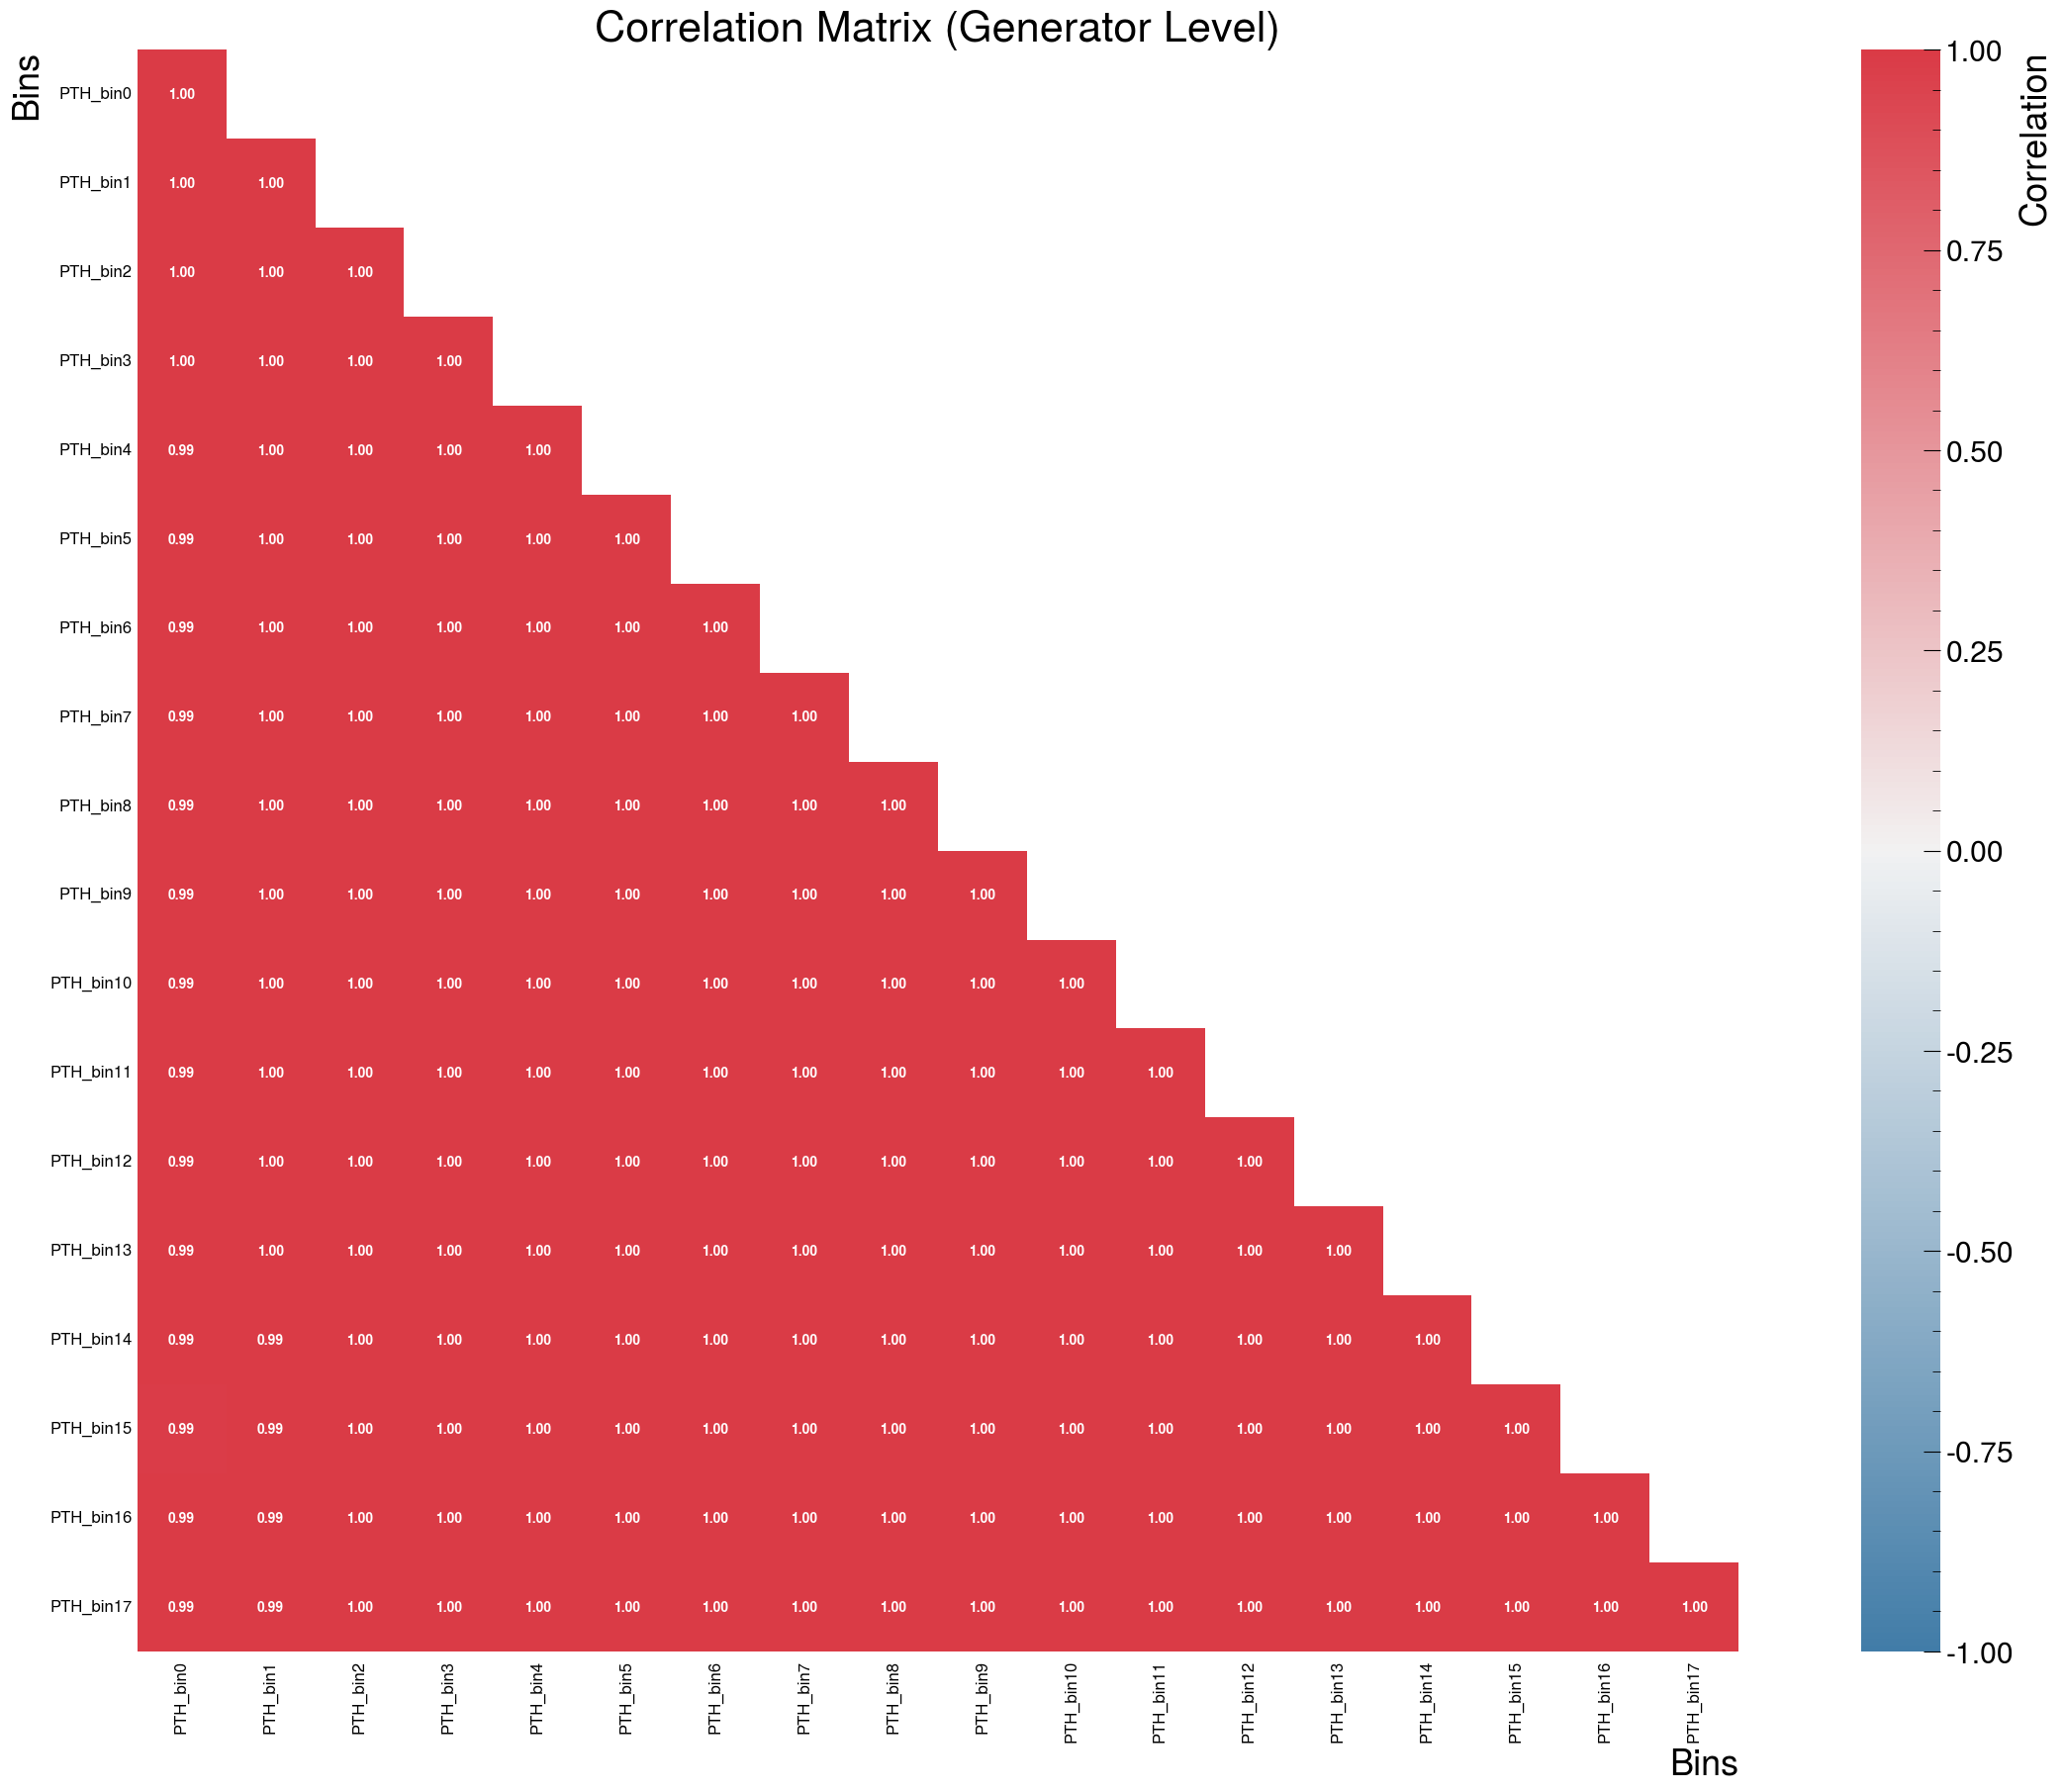

In [49]:
plot_corr(corr)

In [798]:
FILE_RE = re.compile(
    r"^fidXS_(?P<obs>PTH)_all_scale(?P<scale>0|13|57|8)\.py$"
    # r"^fidXS_(?P<obs>PTH)_all_scale(?P<scale>0)\.py$"
)

def load_python_module(path: Path):
    spec = importlib.util.spec_from_file_location(path.stem, path)
    if spec is None or spec.loader is None:
        raise RuntimeError(f"Cannot load file: {path}")
    module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(module)
    return module

scale_variations = {
    "0": {
        "PTH": [],
        # "NJ": [],
        # "PTJ0": [],
        # "YH": [],
    },
    "13": {
        "PTH": [],
        # "NJ": [],
        # "PTJ0": [],
        # "YH": [],
    },
    "57": {
        "PTH": [],
        # "NJ": [],
        # "PTJ0": [],
        # "YH": [],
    },
    "8": {
        "PTH": [],
        # "NJ": [],
        # "PTJ0": [],
        # "YH": [],
    }
}

fidXS_folder = Path("theoretical_uncertainties/fidXS")

for path in fidXS_folder.iterdir():
    print(path)
    match = FILE_RE.match(path.name)
    if not match:
        continue

    obs = match.group("obs")
    scale = match.group("scale")

    module = load_python_module(path)

    if not hasattr(module, "fidXS"):
        print(f"Skipping {path.name}: no fidXS vector")
        continue

    sigma = np.array(list(module.fidXS))  # convert once to numpy
    up = np.array(list(module.fidXS_scale_up))
    dn = np.array(list(module.fidXS_scale_dn))
    
    scale_variations[scale][obs] = up - sigma
    # scale_variations[scale][obs] = 0.5*(up - dn)
    
    

theoretical_uncertainties/fidXS/fidXS_YH_all_scale0.py
theoretical_uncertainties/fidXS/fidXS_YH_all_scale13.py
theoretical_uncertainties/fidXS/fidXS_PTJ0_all_scale8.py
theoretical_uncertainties/fidXS/__pycache__
theoretical_uncertainties/fidXS/fidXS_NJ_all_scale0.py
theoretical_uncertainties/fidXS/fidXS_PTJ0_all_scale13.py
theoretical_uncertainties/fidXS/fidXS_PTH_all_scale57.py
theoretical_uncertainties/fidXS/fidXS_PTH_all_scale8.py
theoretical_uncertainties/fidXS/fidXS_NJ_all_scale57.py
theoretical_uncertainties/fidXS/fidXS_PTH_all_scale0.py
theoretical_uncertainties/fidXS/fidXS_YH_all_scale57.py
theoretical_uncertainties/fidXS/mass_12538
theoretical_uncertainties/fidXS/fidXS_NJ_all_scale8.py
theoretical_uncertainties/fidXS/fidXS_PTJ0_all_scale57.py
theoretical_uncertainties/fidXS/fidXS_PTJ0_all_scale0.py
theoretical_uncertainties/fidXS/fidXS_NJ_all_scale13.py
theoretical_uncertainties/fidXS/fidXS_YH_all_scale8.py
theoretical_uncertainties/fidXS/fidXS_PTH_all_scale13.py


In [ ]:
# Build the correlation matrix
n_bins = len(scale_variations["0"]["PTH"])# + len(scale_variations["0"]["NJ"]) + len(scale_variations["0"]["PTJ0"]) + len(scale_variations["0"]["YH"])
matrix = np.ones((n_bins, n_bins), dtype=int)


label_map = {
    "pth_bin0": "r_PTH_0p0_5p0",
    "pth_bin1": "r_PTH_5p0_10p0",
    "pth_bin2": "r_PTH_10p0_15p0",
    "pth_bin3": "r_PTH_15p0_20p0",
    "pth_bin4": "r_PTH_20p0_25p0",
    "pth_bin5": "r_PTH_25p0_30p0",
    "pth_bin6": "r_PTH_30p0_35p0",
    "pth_bin7": "r_PTH_35p0_45p0",
    "pth_bin8": "r_PTH_45p0_60p0",
    "pth_bin9": "r_PTH_60p0_80p0",
    "pth_bin10": "r_PTH_80p0_100p0",
    "pth_bin11": "r_PTH_100p0_120p0",
    "pth_bin12": "r_PTH_120p0_140p0",
    "pth_bin13": "r_PTH_140p0_170p0",
    "pth_bin14": "r_PTH_170p0_200p0",
    "pth_bin15": "r_PTH_200p0_250p0",
    "pth_bin16": "r_PTH_250p0_350p0",
    "pth_bin17": "r_PTH_350p0_450p0",
    "pth_bin18": "r_PTH_450p0_10000p0"
}

pois = {
    "PTH": ["r_PTH_0p0_5p0","r_PTH_5p0_10p0","r_PTH_10p0_15p0","r_PTH_15p0_20p0","r_PTH_20p0_25p0","r_PTH_25p0_30p0","r_PTH_30p0_35p0","r_PTH_35p0_45p0","r_PTH_45p0_60p0","r_PTH_60p0_80p0","r_PTH_80p0_100p0","r_PTH_100p0_120p0","r_PTH_120p0_140p0","r_PTH_140p0_170p0","r_PTH_170p0_200p0","r_PTH_200p0_250p0","r_PTH_250p0_350p0","r_PTH_350p0_450p0","r_PTH_450p0_10000p0"]
}

# Use the dictionary values (or keys) as labels
labels = list(label_map.values())

correlation = pd.DataFrame(
    matrix,
    index=labels,
    columns=labels
)

In [803]:
# Build the global ordered list of bins
all_bins = []
for obs in pois:
    all_bins.extend(pois[obs])

# Replace the nested dicts with column-vector DataFrames
for source in scale_variations:

    values = []

    for obs in pois:
        values.extend(scale_variations[source][obs])

    scale_variations[source] = pd.DataFrame(
        values,
        index=all_bins,
        columns=[source]
    )

In [806]:
v_0 = scale_variations["0"].iloc[:, 0]
Cov_0 = correlation.mul(v_0, axis=0).mul(v_0, axis=1)

v_13 = scale_variations["13"].iloc[:, 0]
Cov_13 = correlation.mul(v_13, axis=0).mul(v_13, axis=1)

v_57 = scale_variations["57"].iloc[:, 0]
Cov_57 = correlation.mul(v_57, axis=0).mul(v_57, axis=1)

v_8 = scale_variations["0"].iloc[:, 0]
Cov_8 = correlation.mul(v_8, axis=0).mul(v_8, axis=1)

In [809]:
Cov_scale = Cov_0 + Cov_13 + Cov_57 + Cov_8

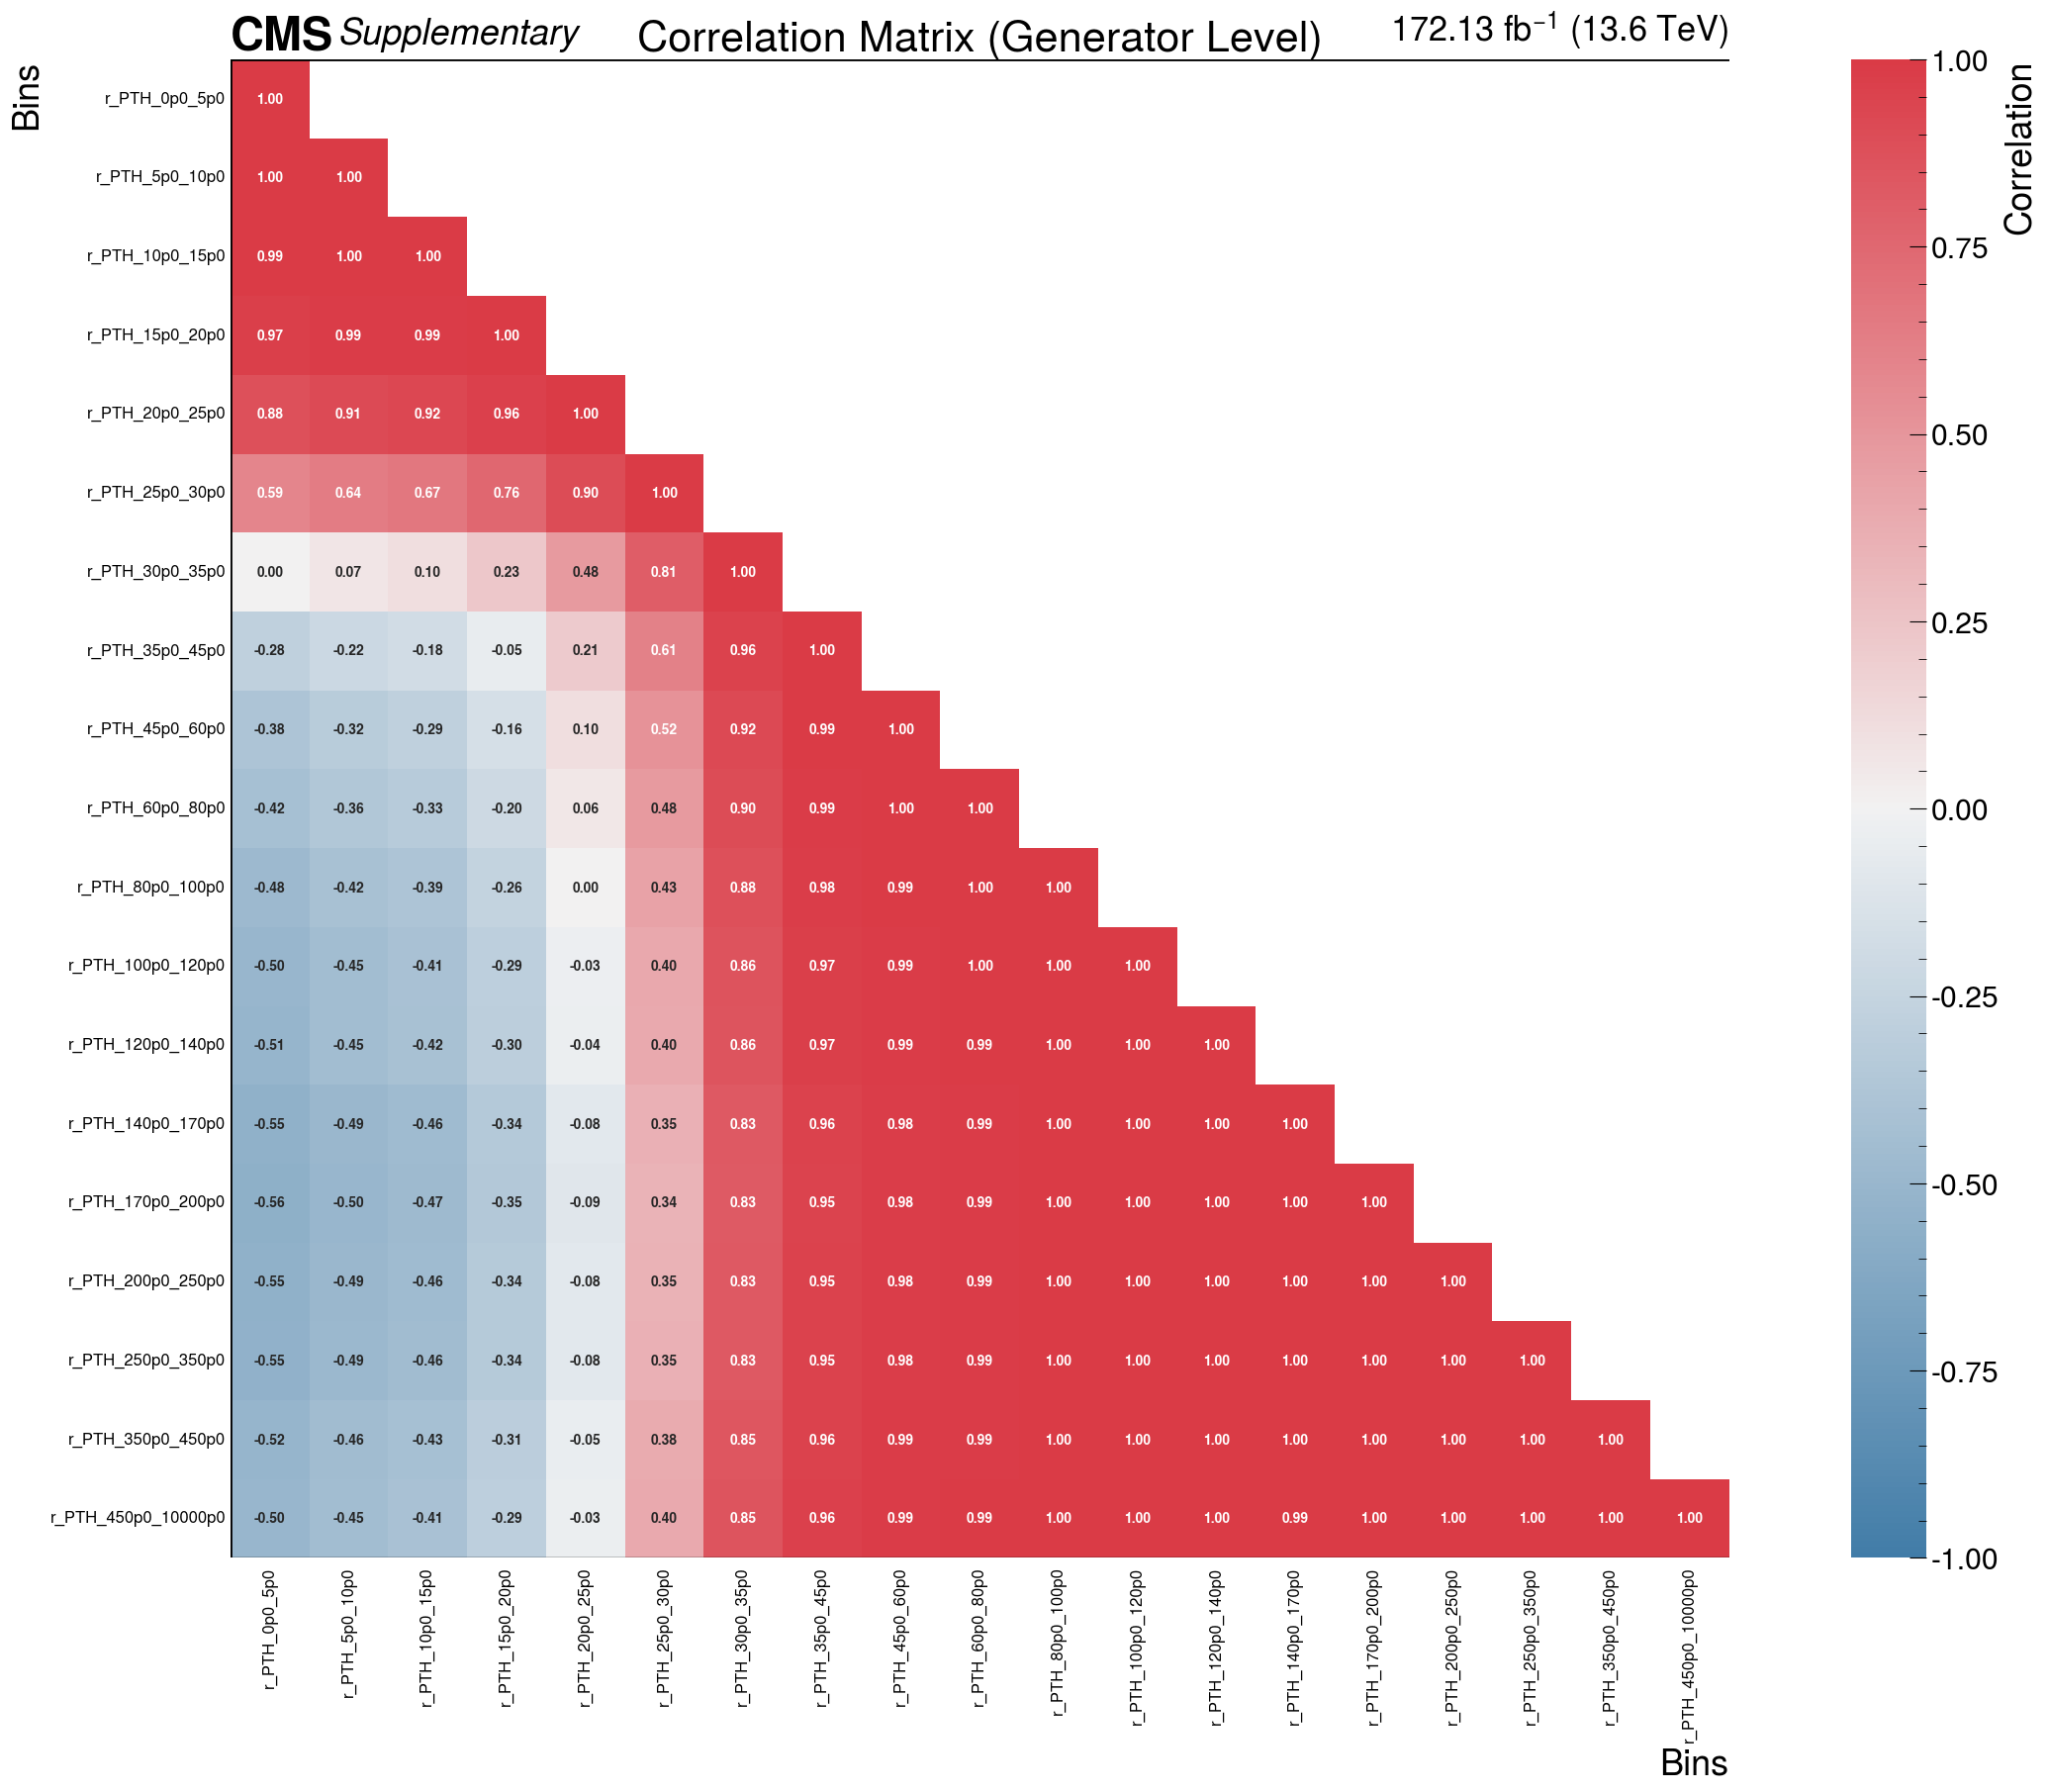

In [812]:
plot_corr(corr_from_cov(Cov_scale))